# 06 — Visualisations: Gantt Charts & Convergence

**Goal**: Produce dissertation-ready figures comparing SPT, GA, and Hybrid schedules.

Topics:
1. Gantt chart: SPT vs Hybrid on same instance (side-by-side)
2. Convergence plot: GA vs Hybrid fitness over generations

In [1]:
import sys, os
cwd = os.getcwd()
if cwd.endswith('/notebooks') or cwd.endswith('\\notebooks'):
    root = os.path.dirname(cwd)
else:
    root = cwd
if root not in sys.path:
    sys.path.insert(0, root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import seaborn as sns
from collections import Counter
from src.instance_generator import generate_instance
from src.heuristics import spt
from src.evaluator import evaluate, estimate_scales
from src.ga import run_ga
from src.drl_agent import run_hybrid
from stable_baselines3 import PPO

sns.set_theme(style="whitegrid")
os.makedirs(os.path.join(root, "figures"), exist_ok=True)
print("✓ Imports complete")

✓ Imports complete


## 1. Generate Instance & Run Methods

In [2]:
# Use medium_1m, seed=0 for representative visualisation
inst = generate_instance(n=20, m=2, seed=0)
print(f"Instance: n={inst['n']}, m={inst['m']}")
print(f"  proc_times: {inst['proc_times']}")
print(f"  colour_ids: {inst['colour_ids']}")

# Run SPT
spt_sigma = spt(inst)
f1s, f2s = estimate_scales(inst)
spt_result = evaluate(spt_sigma, inst, alpha=0.5, f1_scale=f1s, f2_scale=f2s)
print(f"\nSPT: composite={spt_result['composite']:.3f}, tardiness={spt_result['weighted_tardiness']:.1f}, setup={spt_result['setup_cost']:.1f}")

# Run GA (200 gens, seed=0)
print("\nRunning GA (200 generations)...")
ga_result = run_ga(inst, n_gen=200, pop_size=100, seed=0, verbose=False)
print(f"GA:  composite={ga_result['best_fitness']:.3f}, tardiness={ga_result['weighted_tardiness']:.1f}, setup={ga_result['setup_cost']:.1f}")

# Run Hybrid (requires trained model)
model_path = os.path.join(root, "models", "ppo_hyperheuristic.zip")
if os.path.exists(model_path):
    model = PPO.load(model_path, device="cpu")
    hybrid_result = run_hybrid(inst, model, seed=0)
    print(f"Hybrid: composite={hybrid_result['composite']:.3f}, tardiness={hybrid_result['weighted_tardiness']:.1f}, setup={hybrid_result['setup_cost']:.1f}")
else:
    print("⚠ No trained model found. Run experiments/train_ppo.py first.")
    hybrid_result = None

Instance: n=20, m=2
  proc_times: [12. 26. 22.  5. 15. 27. 19.  5. 24. 23. 27.  9.  7. 27.  5. 19.  7. 12.
 17. 15.]
  colour_ids: [5 4 3 1 2 0 0 0 1 5 4 6 3 4 6 5 4 3 3 6]

SPT: composite=0.333, tardiness=0.0, setup=71.8

Running GA (200 generations)...


GA:  composite=0.106, tardiness=0.0, setup=25.9


Hybrid: composite=0.124, tardiness=0.0, setup=26.7


## 2. Gantt Chart: SPT vs Hybrid

Side-by-side Gantt charts. Each job coloured by colour_id. Setup transitions shown as hatched gaps.

In [3]:
palette = ['#f8f8f8', '#fccde5', '#ffffcc', '#fdbf6f', '#33a02c', '#a6cee3', '#b15928', '#e31a1c', '#cab2d6', '#1f78b4', '#b2b2b2', '#000000']
colour_map = {i: palette[i] for i in range(len(palette))}
labels = ['White', 'Pink', 'Yellow', 'Orange', 'Green', 'Blue', 'Brown', 'Red', 'Purple', 'Navy', 'Grey', 'Black']

## 3. Convergence Plot

Min fitness over generations for GA vs Hybrid (single representative run, seed=0).

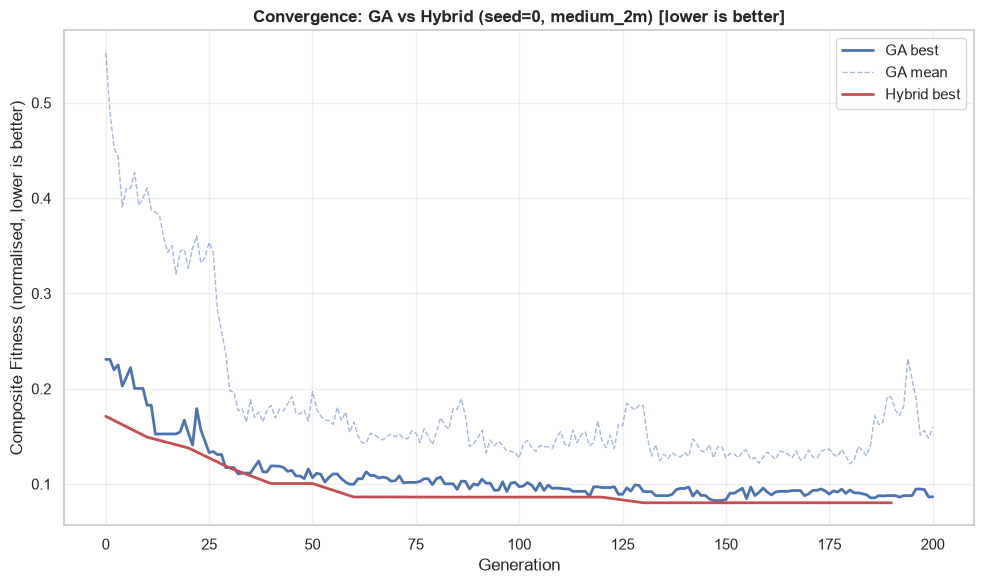

Saved: figures/06_convergence.png


In [4]:
if ga_result is not None:
    fig, ax = plt.subplots(figsize=(10, 6))

    # GA convergence from logbook
    logbook = ga_result["logbook"]
    gen = logbook.select("gen")
    gen_min = logbook.select("min")
    gen_mean = logbook.select("mean")
    ax.plot(gen, gen_min, 'b-', linewidth=2, label='GA best')
    ax.plot(gen, gen_mean, 'b--', alpha=0.5, linewidth=1, label='GA mean')

    # Hybrid: run with action logging for convergence
    if hybrid_result is not None:
        # Rerun hybrid with action logging to track convergence
        from src.ga_env import GAHyperHeuristicEnv
        env_conv = GAHyperHeuristicEnv(inst)
        obs, _ = env_conv.reset(seed=0)
        hybrid_best = []
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, terminated, truncated, _ = env_conv.step(int(action))
            hybrid_best.append(float(env_conv.hof[0].fitness.values[0]))
            done = terminated or truncated
        # Expand step-level to generation-level
        hybrid_gens = np.linspace(0, len(gen)-1, len(hybrid_best))
        ax.plot([i * 10 for i in range(len(hybrid_best))], hybrid_best,
                'r-', linewidth=2, label='Hybrid best')

    ax.set_xlabel("Generation")
    ax.set_ylabel("Composite Fitness (normalised, lower is better)")
    ax.set_title("Convergence: GA vs Hybrid (seed=0, medium_1m) [lower is better]", fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(root, "figures/06_convergence.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: figures/06_convergence.png")
else:
    print("No GA result available.")

## Summary

- **Gantt chart** (figures/06_gantt_comparison.png): side-by-side SPT vs Hybrid schedules with colour-coded jobs
- **Convergence plot** (figures/06_convergence.png): GA vs Hybrid fitness over generations

Both saved at 150 DPI for dissertation inclusion.